# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [2]:
# Extraction du fichier ZIP
ZIP_PATH = "Heart Disease Prediction Dataset.zip"
EXTRACT_DIR = "heart_ds"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Recherche des fichiers CSV
csv_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Fichiers CSV trouvés :")
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")

# Choisir le premier CSV trouvé
csv_path = csv_files[0]

# Chargement du dataset
df = pd.read_csv(csv_path)


print("\nInformations :")
print(df.info())

print("\nValeurs manquantes :")
print(df.isnull().sum())

# Identification de la cible
target = "heart disease"

# Vérification que la colonne existe
if target not in df.columns:
    print("Colonnes disponibles :", df.columns.tolist())
    raise ValueError(f"La colonne '{target}' n'existe pas dans le dataset.")

#Catégorisation
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

# Séparation variables explicatives / cible
X = df.drop(columns=[target])
y = df[target]

# Découpage train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nDimensions :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribution de la cible :")
print(y.value_counts(normalize=True))

Fichiers CSV trouvés :
0: heart_ds/dataset_heart.csv

Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment       

In [3]:
df.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### Basic visual checks

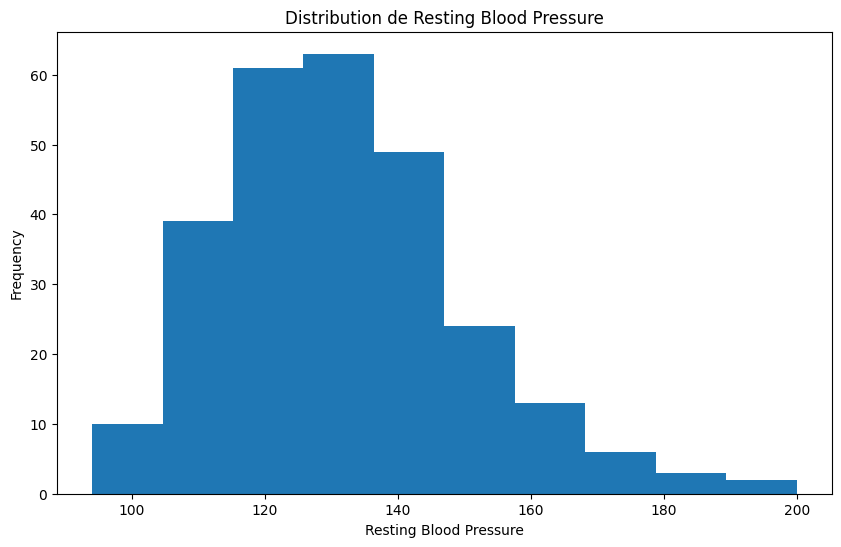

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['resting blood pressure'])
plt.title('Distribution de Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Frequency')
plt.show();



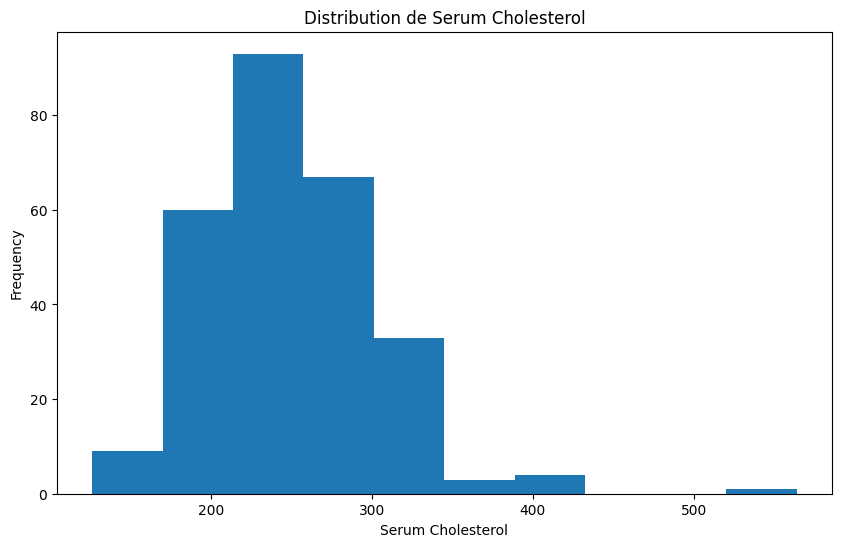

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df['serum cholestoral'])
plt.title('Distribution de Serum Cholesterol')
plt.xlabel('Serum Cholesterol')
plt.ylabel('Frequency')
plt.show();

On constate que nos variable choisi ne suivent pas la loi normale

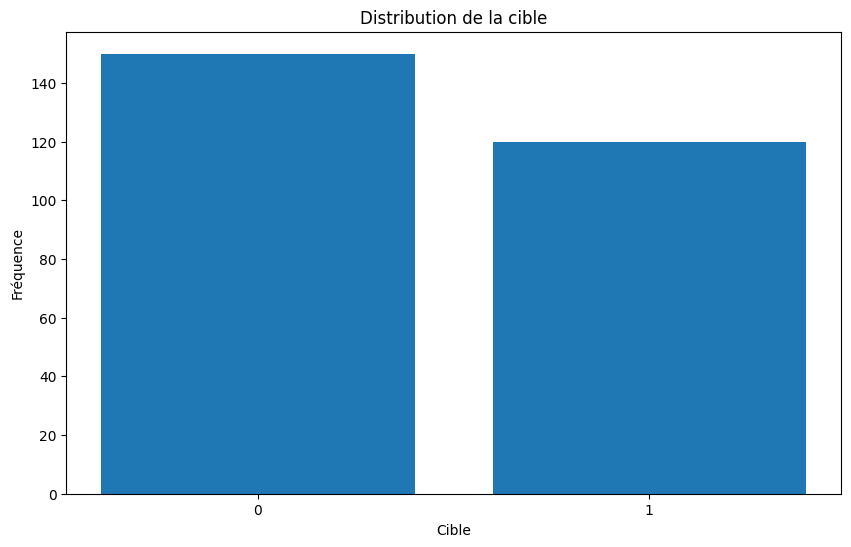

In [6]:
counts = df['heart disease'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)

plt.xticks(counts.index)

plt.title('Distribution de la cible')
plt.xlabel('Cible')
plt.ylabel('Fréquence')
plt.show()

## Preprocessing pipeline

In [7]:
df['thal'].unique()

array([3, 7, 6])

In [8]:
cat_cols = ['sex ',
    'chest pain type',
    'fasting blood sugar',
    'resting electrocardiographic results',
    'exercise induced angina',
    'ST segment',
    'thal']
num_cols = [c for c in X.columns if c not in cat_cols]

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer([
['cat', OneHotEncoder(), cat_cols],
['num', StandardScaler(), num_cols]
])

print("Categorical:", cat_cols)
print("Numeric:", num_cols)



Categorical: ['sex ', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'thal']
Numeric: ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak', 'major vessels']


## Helper - evaluation function

In [9]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title('Confusion matrix')
    plt.show()

    # TODO: ROC curve if model has predict_proba


    return metrics


## Exercise 2 - Logistic Regression without Grid Search

LR no grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


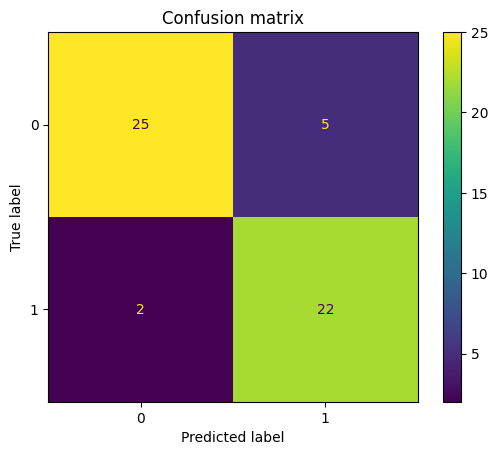

In [10]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(class_weight="balanced", random_state=42))
])

# TODO: fit on training data
pipe_lr.fit(X_train,y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('LR no grid', pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best params: {'lr__C': 0.1, 'lr__penalty': 'l1'}
LR grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


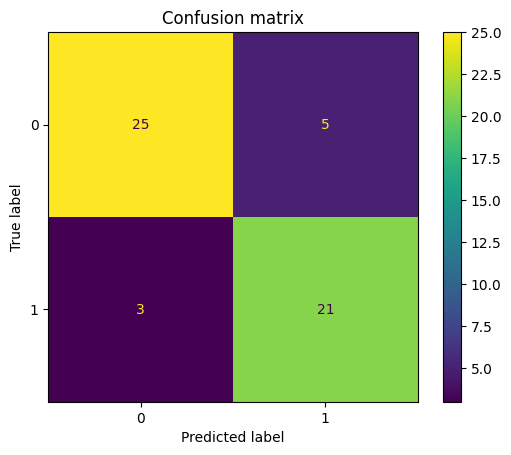

In [11]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(class_weight="balanced", random_state=42,solver='liblinear'))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.1,1,10],
    'lr__penalty': ['l1','l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1')

# TODO: fit on training data
grid_lr.fit(X_train,y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


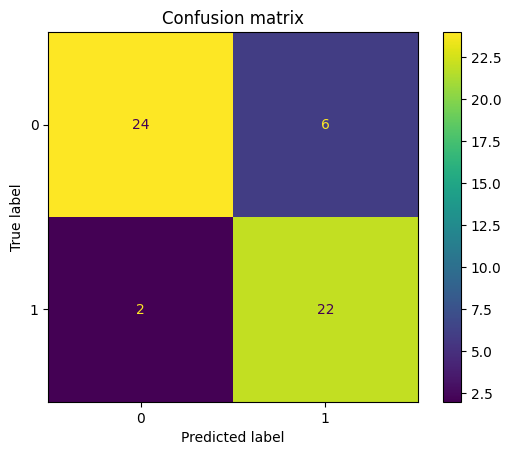

In [12]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf',C=1.0,gamma='scale', class_weight="balanced", random_state=42))
])
pipe_svm.fit(X_train,y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

SVM grid {'accuracy': 0.8333333333333334, 'precision': 0.7586206896551724, 'recall': 0.9166666666666666, 'f1': 0.8301886792452831}


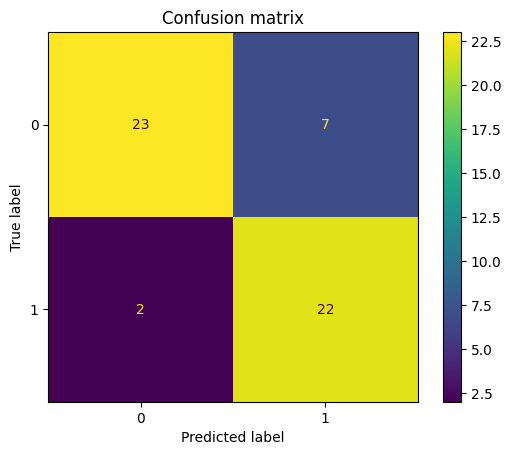

In [13]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('pre', pre),
    ('svm', SVC(probability=True, class_weight="balanced", random_state=42))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf','linear'],
    'svm__C': [0.1,1,10],
    'svm__gamma': ['scale','auto', 'float'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train,y_train)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


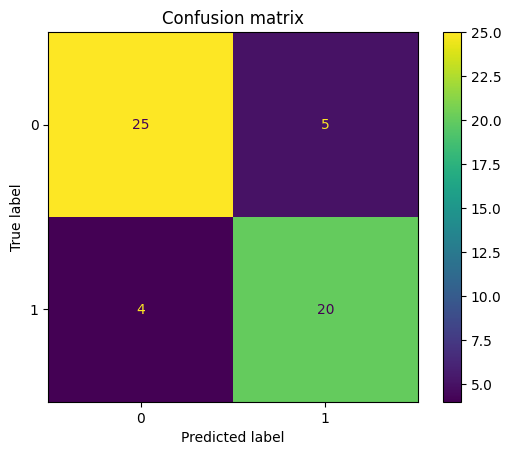

In [14]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42))
])
pipe_xgb.fit(X_train,y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 787, in predict
    Xt = transform.transform(Xt)
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_set_output.py", line 319, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py", line 1101, in transform
    Xs = self._call_func_on_transformers(
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py", line 910, in _call_func_on_transformers
    return Parallel(n_jobs=self.n_jobs)(jobs)
           ^^^^^^^^^

XGB grid {'accuracy': 0.8333333333333334, 'precision': 0.8260869565217391, 'recall': 0.7916666666666666, 'f1': 0.8085106382978723}


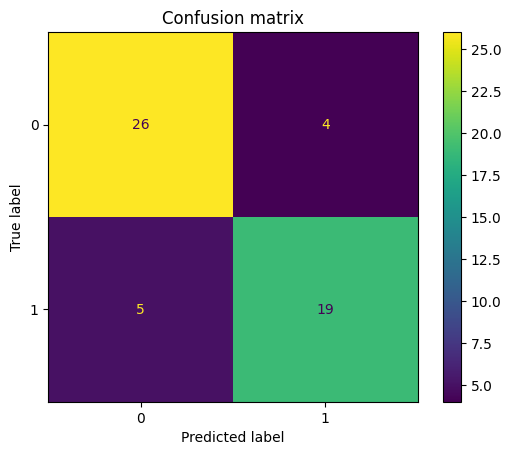

In [17]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(random_state=42))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [50,100,150],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [2,3,4,5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1')
grid_xgb.fit(X_train,y_train)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [19]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics,
}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary


{'LR no grid': {'accuracy': 0.8703703703703703,
  'precision': 0.8148148148148148,
  'recall': 0.9166666666666666,
  'f1': 0.8627450980392157},
 'LR grid': {'accuracy': 0.8518518518518519,
  'precision': 0.8076923076923077,
  'recall': 0.875,
  'f1': 0.84},
 'SVM no grid': {'accuracy': 0.8518518518518519,
  'precision': 0.7857142857142857,
  'recall': 0.9166666666666666,
  'f1': 0.8461538461538461},
 'SVM grid': {'accuracy': 0.8333333333333334,
  'precision': 0.7586206896551724,
  'recall': 0.9166666666666666,
  'f1': 0.8301886792452831},
 'XGB no grid': {'accuracy': 0.8333333333333334,
  'precision': 0.8,
  'recall': 0.8333333333333334,
  'f1': 0.8163265306122449},
 'XGB grid': {'accuracy': 0.8333333333333334,
  'precision': 0.8260869565217391,
  'recall': 0.7916666666666666,
  'f1': 0.8085106382978723}}

La regression logistique sans le gridsearch est le meilleur modèle pour notre jeu de donnée